In [6]:
import stim
import mwpf.ref_circuit

In [7]:
CONVERT_INSTRUCTIONS = ("DEPOLARIZE1", "DEPOLARIZE2")
CONVERSION_FACTOR = 1

orig_circuit = stim.Circuit.generated(
    "surface_code:rotated_memory_x",
    rounds=3,
    distance=3,
    after_clifford_depolarization=0.75,
    after_reset_flip_probability=0.75,
)

ref_circuit = mwpf.ref_circuit.RefCircuit.of(orig_circuit)
instructions = []
for instruction in ref_circuit:
    if instruction.name in CONVERT_INSTRUCTIONS:
        p = instruction.gate_args[0]
        new_instruction = mwpf.ref_circuit.RefInstruction.new_heralded_erase(
            instruction.targets, min(1, 4 / 3 * p * CONVERSION_FACTOR)
        )
        instructions.append(new_instruction)
        for rec in new_instruction.recs:
            instructions.append(mwpf.ref_circuit.RefInstruction.new_detector((rec,)))
    else:
        instructions.append(instruction)

surface_code_circuit = mwpf.ref_circuit.RefCircuit.of(instructions).circuit

In [8]:
surface_code_circuit.diagram("timeline-text")

/----------------------------------------------\ /-------------------------------------------\ /----------------------------------------------\ /--------------------------------------------------------------------------\ /--------------------------------------------------------------------------\ /----------------------------------------------------------------------------\ /----------------------------------------------\ /--------------------------------------------------\ /----------------------------------------------\ /----------------------------------------------\ /--------------------------------------------------------------------------\ /----------------------------------------------------------------------------\ /--------------------------------------------------------------------------------\ /-------------------------------------------------\ /-------------------------------------------------------------\ /-------------------------------------------------\ /-------------------------------------------------\ /------------------------------------------------------------------------------\ /------------------------------------------------------------------------------\ /--------------------------------------------------------------------------------\ /-------------------------------------------------\ /--------------------------------------------------------------------------------------------------------------------------------\
 q0: -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

 q1: -QUBIT_COORDS(1,1)-RX-Z_ERROR(0.75)--------------------------------------------------------------------------------------------------------------X---HERALDED_ERASE(1):rec[17]-DETECTOR:D17=rec[17]------------------------------------------------------------------------------------------------------------@---------------------------HERALDED_ERASE(1):rec[46]-DETECTOR:D46=rec[46]---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------X---HERALDED_ERASE(1):rec[81]-DETECTOR:D77=rec[81]--------------------------------------------------------------------------------------------------------------@----------------------------HERALDED_ERASE(1):rec[110]-DETECTOR:D106=rec[110]-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------X---HERALDED_ERASE(1):

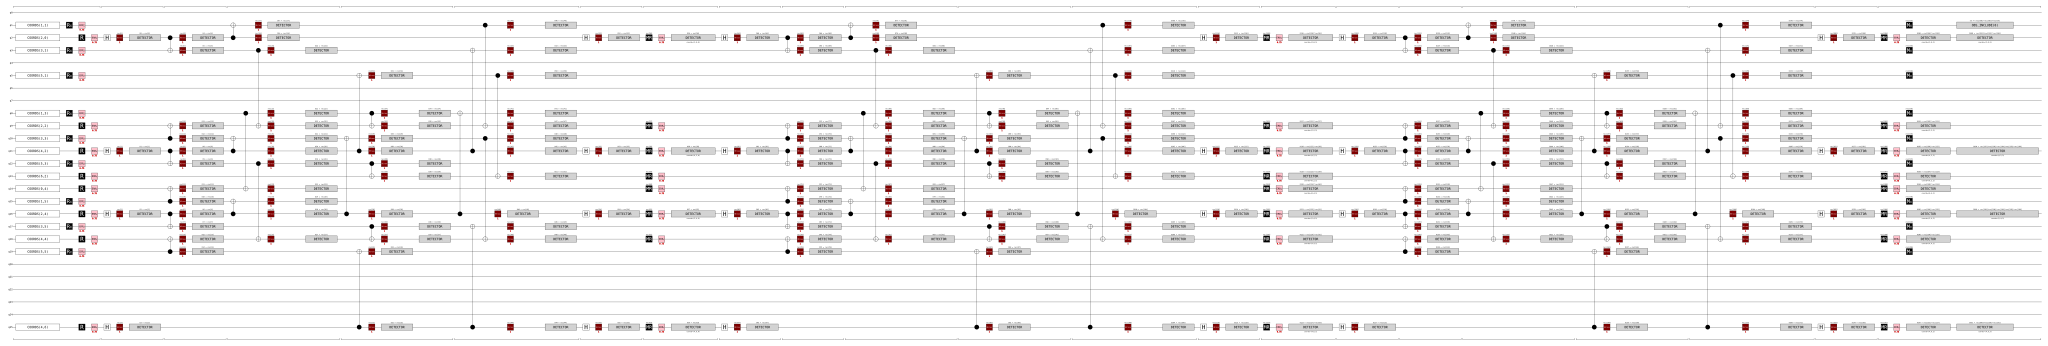

In [9]:
surface_code_circuit.diagram("timeline-svg")

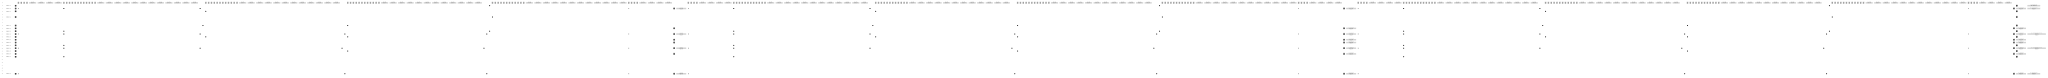

In [10]:
surface_code_circuit.without_noise().diagram("timeline-svg")

In [11]:
surface_code_circuit.diagram("timeline-3d")

{"accessors":[{"bufferView":0,"byteOffset":0,"componentType":5126,"count":12,"max":[0,0.5,0.5],"min":[0,-0.5,-0.5],"name":"cube","type":"VEC3"},{"bufferView":1,"byteOffset":0,"componentType":5126,"count":12,"max":[0.375,0.4375],"min":[0.3125,0.375],"name":"tex_coords_gate_RX","type":"VEC2"},{"bufferView":2,"byteOffset":0,"componentType":5126,"count":12,"max":[0.5,0.5625],"min":[0.4375,0.5],"name":"tex_coords_gate_Z_ERROR","type":"VEC2"},{"bufferView":3,"byteOffset":0,"componentType":5126,"count":12,"max":[0.375,0.5625],"min":[0.3125,0.5],"name":"tex_coords_gate_R","type":"VEC2"},{"bufferView":4,"byteOffset":0,"componentType":5126,"count":12,"max":[0.5,0.4375],"min":[0.4375,0.375],"name":"tex_coords_gate_X_ERROR","type":"VEC2"},{"bufferView":5,"byteOffset":0,"componentType":5126,"count":12,"max":[0.125,0.5],"min":[0.0625,0.4375],"name":"tex_coords_gate_H","type":"VEC2"},{"bufferView":6,"byteOffset":0,"componentType":5126,"count":12,"max":[0.9375,0.625],"min":[0.875,0.5625],"name":"tex_coords_gate_HERALDED_ERASE","type":"VEC2"},{"bufferView":7,"byteOffset":0,"componentType":5126,"count":17,"max":[0,0.400000005960464,0.400000005960464],"min":[0,-0.400000005960464,-0.400000005960464],"name":"circle_loop","type":"VEC3"},{"bufferView":8,"byteOffset":0,"componentType":5126,"count":17,"max":[0,0.400000005960464,0.400000005960464],"min":[0,-0.400000005960464,-0.400000005960464],"name":"circle_loop","type":"VEC3"},{"bufferView":9,"byteOffset":0,"componentType":5126,"count":4,"max":[0,0.400000005960464,0.400000005960464],"min":[0,-0.400000005960464,-0.400000005960464],"name":"control_x_line_cross","type":"VEC3"},{"bufferView":10,"byteOffset":0,"componentType":5126,"count":12,"max":[0.4375,0.5625],"min":[0.375,0.5],"name":"tex_coords_gate_MR","type":"VEC2"},{"bufferView":11,"byteOffset":0,"componentType":5126,"count":12,"max":[0.3125,0.4375],"min":[0.25,0.375],"name":"tex_coords_gate_MX","type":"VEC2"},{"bufferView":12,"byteOffset":0,"componentType":5126,"count":178,"max":[1,-32,-32],"min":[-45,-40.4852828979492,-40.4852828979492],"name":"buf_scattered_lines","type":"VEC3"},{"bufferView":13,"byteOffset":0,"componentType":5126,"count":6,"max":[0,-29.5,-36.2426414489746],"min":[-3,-30.5,-36.2426414489746],"name":"buf_red_scattered_lines","type":"VEC3"},{"bufferView":14,"byteOffset":0,"componentType":5126,"count":336,"max":[0.25,-31.2000007629395,-31.5],"min":[-42.25,-31.6000003814697,-40.9852828979492],"name":"buf_blue_scattered_lines","type":"VEC3"}],"asset":{"version":"2.0"},"bufferViews":[{"buffer":0,"byteLength":144,"byteOffset":0,"name":"cube","target":34962},{"buffer":1,"byteLength":96,"byteOffset":0,"name":"tex_coords_gate_RX","target":34962},{"buffer":2,"byteLength":96,"byteOffset":0,"name":"tex_coords_gate_Z_ERROR","target":34962},{"buffer":3,"byteLength":96,"byteOffset":0,"name":"tex_coords_gate_R","target":34962},{"buffer":4,"byteLength":96,"byteOffset":0,"name":"tex_coords_gate_X_ERROR","target":34962},{"buffer":5,"byteLength":96,"byteOffset":0,"name":"tex_coords_gate_H","target":34962},{"buffer":6,"byteLength":96,"byteOffset":0,"name":"tex_coords_gate_HERALDED_ERASE","target":34962},{"buffer":7,"byteLength":204,"byteOffset":0,"name":"circle_loop","target":34962},{"buffer":8,"byteLength":204,"byteOffset":0,"name":"circle_loop","target":34962},{"buffer":9,"byteLength":48,"byteOffset":0,"name":"control_x_line_cross","target":34962},{"buffer":10,"byteLength":96,"byteOffset":0,"name":"tex_coords_gate_MR","target":34962},{"buffer":11,"byteLength":96,"byteOffset":0,"name":"tex_coords_gate_MX","target":34962},{"buffer":12,"byteLength":2136,"byteOffset":0,"name":"buf_scattered_lines","target":34962},{"buffer":13,"byteLength":72,"byteOffset":0,"name":"buf_red_scattered_lines","target":34962},{"buffer":14,"byteLength":4032,"byteOffset":0,"name":"buf_blue_scattered_lines","target":34962}],"buffers":[{"byteLength":144,"name":"cube","uri":"data:application/octet-stream;base64,AAAAAAAAAD8AAAA/AAAAAAAAAD8AAAC/AAAAAAAAAL8AAAA/AAAAAAAAAD8AAAC/AA

In [12]:
surface_code_circuit.without_noise().diagram("timeline-3d")

{"accessors":[{"bufferView":0,"byteOffset":0,"componentType":5126,"count":12,"max":[0,0.5,0.5],"min":[0,-0.5,-0.5],"name":"cube","type":"VEC3"},{"bufferView":1,"byteOffset":0,"componentType":5126,"count":12,"max":[0.375,0.4375],"min":[0.3125,0.375],"name":"tex_coords_gate_RX","type":"VEC2"},{"bufferView":2,"byteOffset":0,"componentType":5126,"count":12,"max":[0.375,0.5625],"min":[0.3125,0.5],"name":"tex_coords_gate_R","type":"VEC2"},{"bufferView":3,"byteOffset":0,"componentType":5126,"count":12,"max":[0.125,0.5],"min":[0.0625,0.4375],"name":"tex_coords_gate_H","type":"VEC2"},{"bufferView":4,"byteOffset":0,"componentType":5126,"count":12,"max":[0.875,0.625],"min":[0.8125,0.5625],"name":"tex_coords_gate_MPAD","type":"VEC2"},{"bufferView":5,"byteOffset":0,"componentType":5126,"count":17,"max":[0,0.400000005960464,0.400000005960464],"min":[0,-0.400000005960464,-0.400000005960464],"name":"circle_loop","type":"VEC3"},{"bufferView":6,"byteOffset":0,"componentType":5126,"count":17,"max":[0,0.400000005960464,0.400000005960464],"min":[0,-0.400000005960464,-0.400000005960464],"name":"circle_loop","type":"VEC3"},{"bufferView":7,"byteOffset":0,"componentType":5126,"count":4,"max":[0,0.400000005960464,0.400000005960464],"min":[0,-0.400000005960464,-0.400000005960464],"name":"control_x_line_cross","type":"VEC3"},{"bufferView":8,"byteOffset":0,"componentType":5126,"count":12,"max":[0.4375,0.5625],"min":[0.375,0.5],"name":"tex_coords_gate_MR","type":"VEC2"},{"bufferView":9,"byteOffset":0,"componentType":5126,"count":12,"max":[0.3125,0.4375],"min":[0.25,0.375],"name":"tex_coords_gate_MX","type":"VEC2"},{"bufferView":10,"byteOffset":0,"componentType":5126,"count":180,"max":[1,-0,-0],"min":[-172,-40.4852828979492,-40.4852828979492],"name":"buf_scattered_lines","type":"VEC3"},{"bufferView":11,"byteOffset":0,"componentType":5126,"count":6,"max":[0,2.5,-20.2426414489746],"min":[-3,1.5,-20.2426414489746],"name":"buf_red_scattered_lines","type":"VEC3"},{"bufferView":12,"byteOffset":0,"componentType":5126,"count":288,"max":[-0.75,0.800000011920929,0.5],"min":[-170.25,0.400000005960464,-40.9852828979492],"name":"buf_blue_scattered_lines","type":"VEC3"}],"asset":{"version":"2.0"},"bufferViews":[{"buffer":0,"byteLength":144,"byteOffset":0,"name":"cube","target":34962},{"buffer":1,"byteLength":96,"byteOffset":0,"name":"tex_coords_gate_RX","target":34962},{"buffer":2,"byteLength":96,"byteOffset":0,"name":"tex_coords_gate_R","target":34962},{"buffer":3,"byteLength":96,"byteOffset":0,"name":"tex_coords_gate_H","target":34962},{"buffer":4,"byteLength":96,"byteOffset":0,"name":"tex_coords_gate_MPAD","target":34962},{"buffer":5,"byteLength":204,"byteOffset":0,"name":"circle_loop","target":34962},{"buffer":6,"byteLength":204,"byteOffset":0,"name":"circle_loop","target":34962},{"buffer":7,"byteLength":48,"byteOffset":0,"name":"control_x_line_cross","target":34962},{"buffer":8,"byteLength":96,"byteOffset":0,"name":"tex_coords_gate_MR","target":34962},{"buffer":9,"byteLength":96,"byteOffset":0,"name":"tex_coords_gate_MX","target":34962},{"buffer":10,"byteLength":2160,"byteOffset":0,"name":"buf_scattered_lines","target":34962},{"buffer":11,"byteLength":72,"byteOffset":0,"name":"buf_red_scattered_lines","target":34962},{"buffer":12,"byteLength":3456,"byteOffset":0,"name":"buf_blue_scattered_lines","target":34962}],"buffers":[{"byteLength":144,"name":"cube","uri":"data:application/octet-stream;base64,AAAAAAAAAD8AAAA/AAAAAAAAAD8AAAC/AAAAAAAAAL8AAAA/AAAAAAAAAD8AAAC/AAAAAAAAAL8AAAC/AAAAAAAAAL8AAAA/AAAAAAAAAL8AAAC/AAAAAAAAAD8AAAC/AAAAAAAAAL8AAAA/AAAAAAAAAL8AAAA/AAAAAAAAAD8AAAC/AAAAAAAAAD8AAAA/"},{"byteLength":96,"name":"tex_coords_gate_RX","uri":"data:application/octet-stream;base64,AADAPgAAwD4AAKA+AADAPgAAwD4AAOA+AACgPgAAwD4AAKA+AADgPgAAwD4AAOA+AADAPgAA4D4AAMA+AADAPgAAoD4AAOA+AACgPgAA4D4AAMA+AADAPgAAoD4AAMA+"},{"byteLength":96,"name":"tex_coords_gate_R","uri":"data:application/octet-stream;base64,AADAPgAAAD8AAKA+AAAAPwAAwD4AABA/AACgPgAAAD8AAKA+AAAQPwAAwD4AABA/AADAPgAAED8A

In [13]:
surface_code_circuit.without_noise().diagram("detslice-text")

q0: --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

 q1:(1, 1) -X:D56----------X:D56------------------X:D56---------------------------------------X:D116----------------------------------------------------------------X:D116----------------------------------------------------------X:D116--Z:D117--------------------------------------------------X:D116--Z:D117------------------------------------------X:D116--Z:D117--------------------------------------------------X:D116--Z:D117--------------------------------------------------X:D116--Z:D117----------------------------------------------------------Z:D117----------------------------------X:D180--------------------------------------------------Z:D117----------------------------------X:D180----------------------------------------------------------X:D180--Z:D181--------------------------------------------------X:D180--Z:D181------------------------------------------X:D180--Z:D181--------------------------------------------------X:D180--Z:D181--------------------------------------------------X:D180--Z:D181----------------------------------------------------------Z:D181----------------------------------X:D188------------------Z:D181----------------------------------X:D188------------------X:D188------------------X:D188-----------------
            |              |                      |                                           |                                                                     |                                                               |       |                                                       |       |                                               |       |                                                       |       |                                                       |       |                                                               |                                       |                                                       |                                       |                                                               |       |                                                       |       |                                               |       |                                                       |       |                                                       |       |                                                               |                                       |                       |                                       |                       |                       |
 q2:(2, 0) -Z:D56--Z:D116--X:D56----------X:D116--X:D56-----------------X:D116--X:D56---------X:D116------------------------------------------X:D56-----------------X:D116--------------------------------------------------X:D56---X:D116--|-----------------------------------------------Z:D56---Z:D1

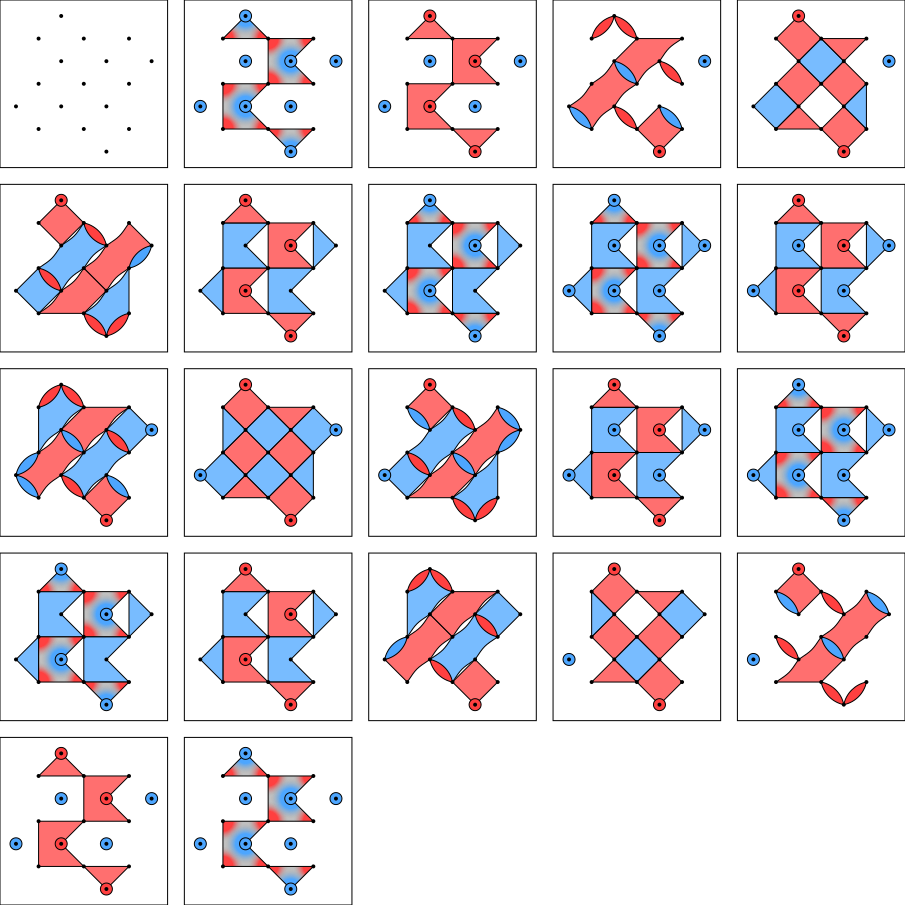

In [14]:
surface_code_circuit.diagram("detslice-svg")

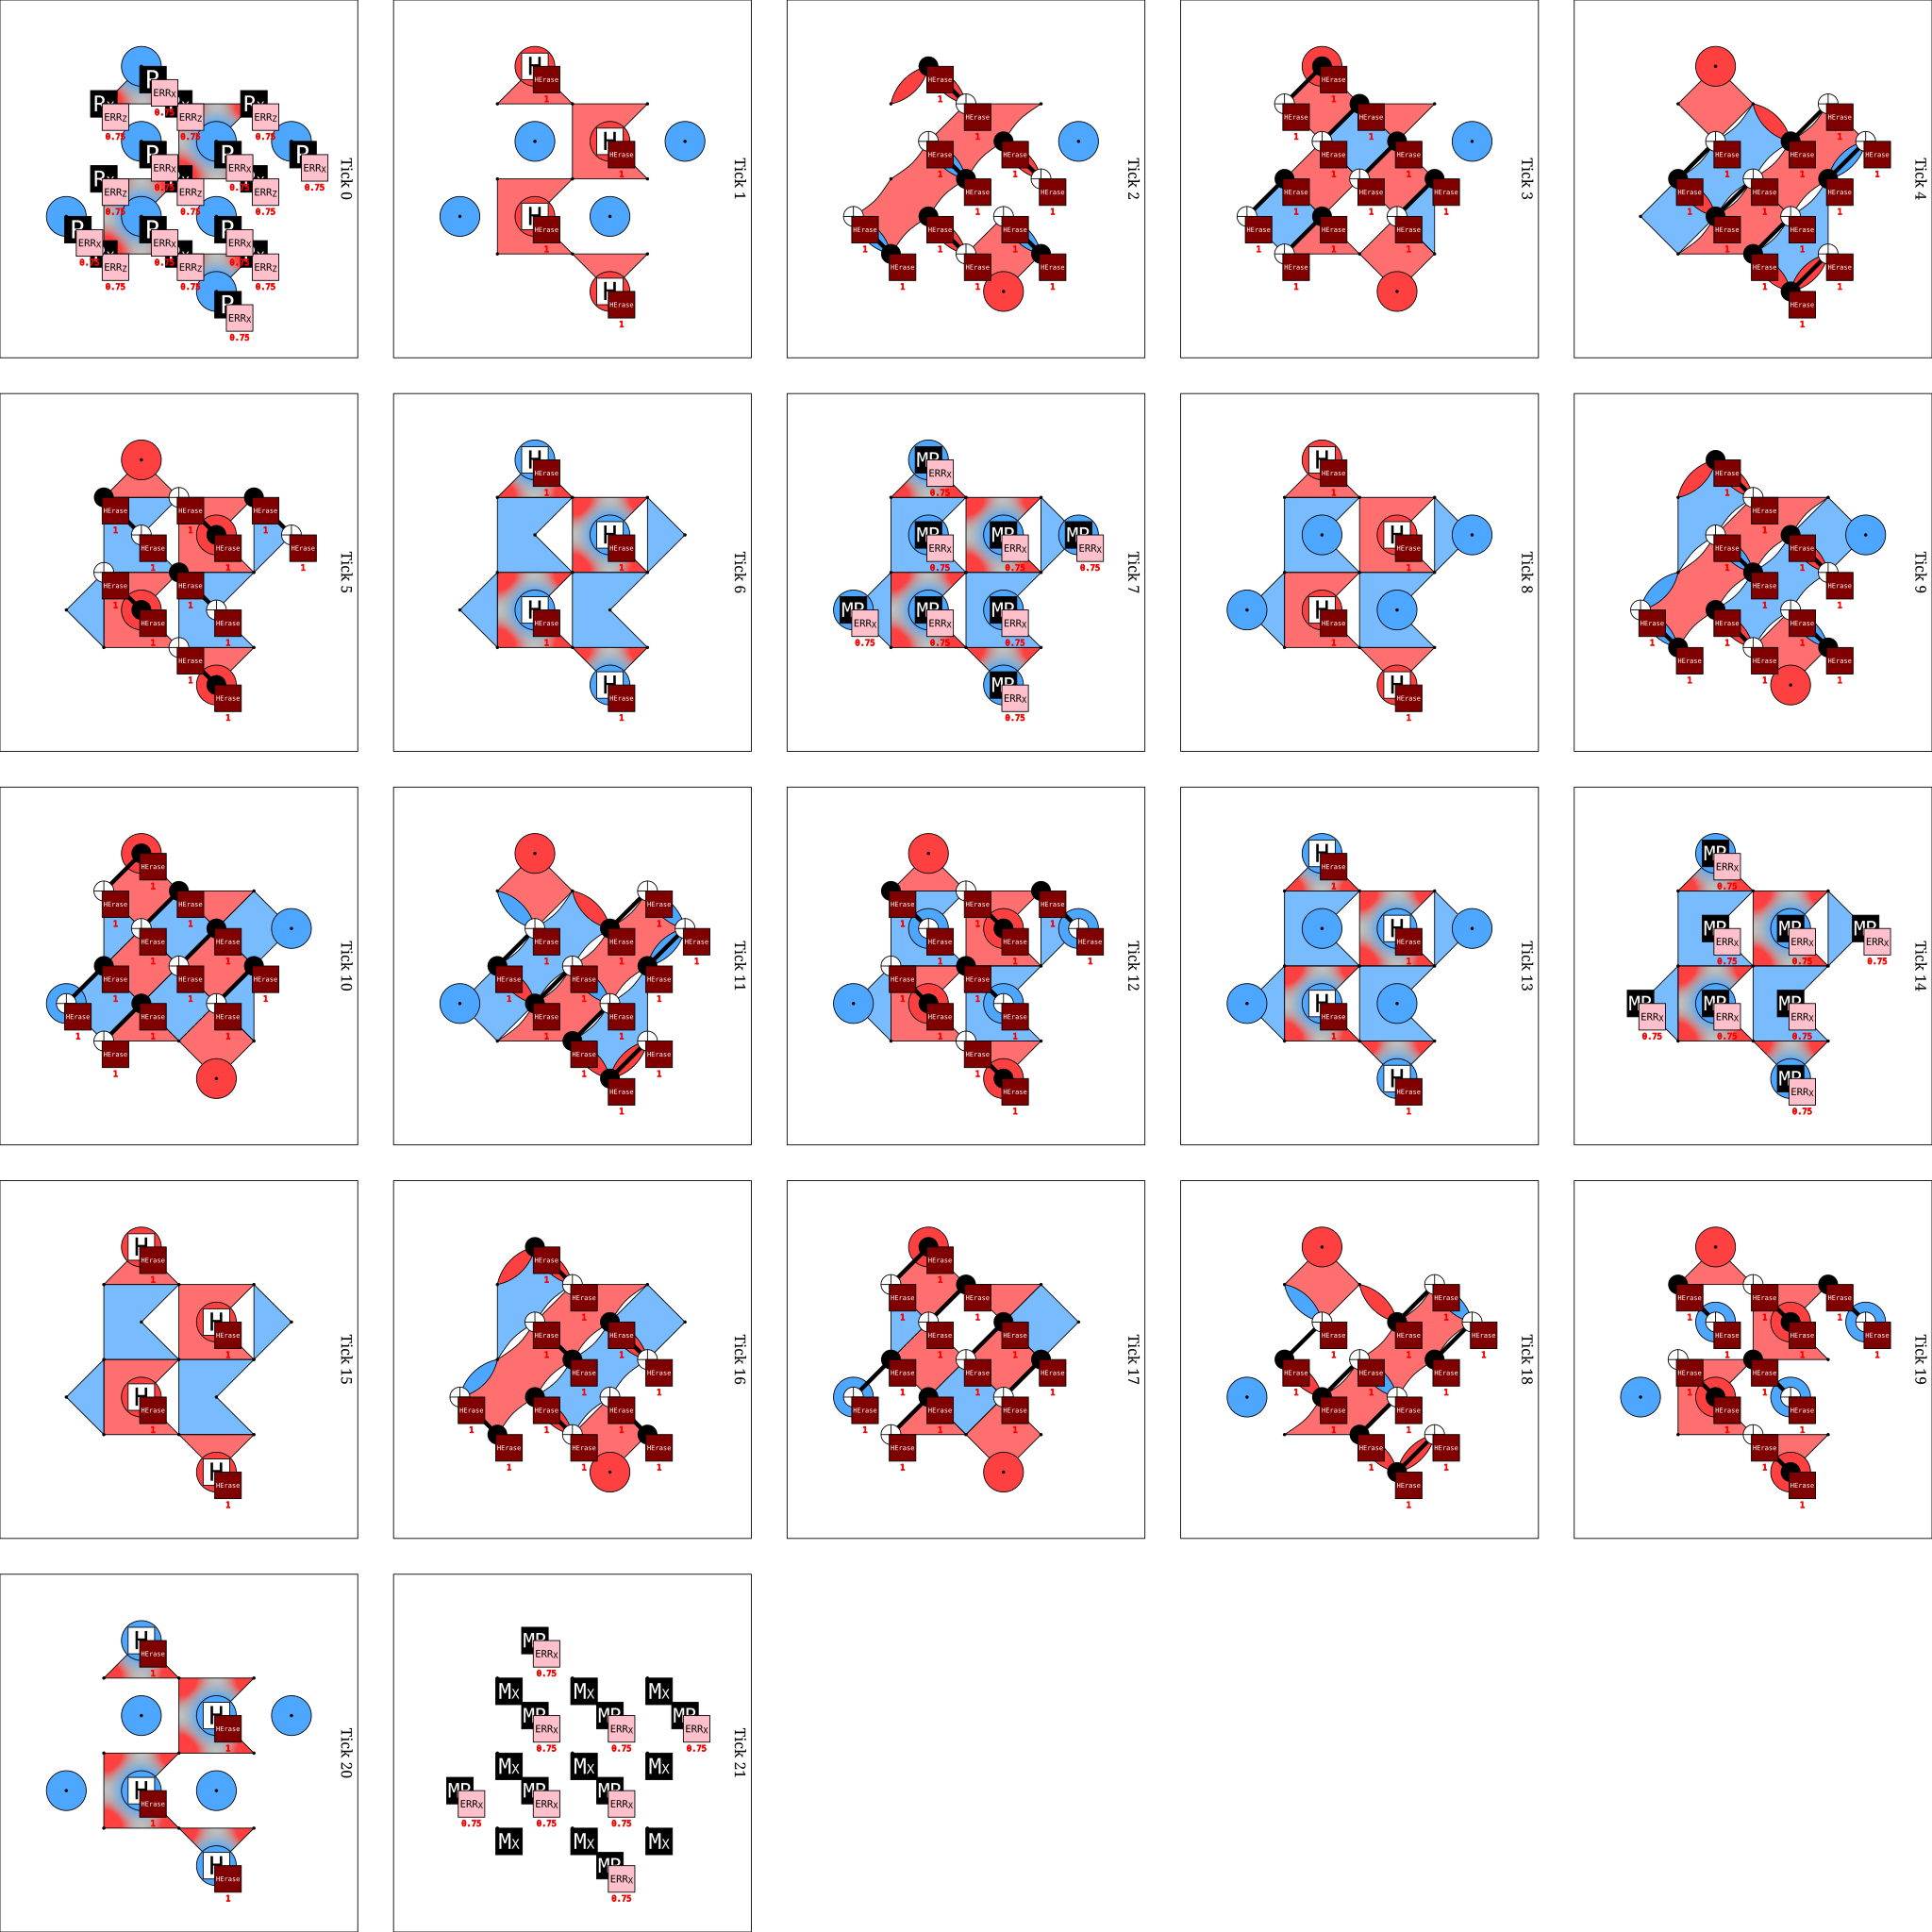

In [15]:
surface_code_circuit.diagram("detslice-with-ops-svg")

In [16]:
surface_code_circuit.diagram("matchgraph-3d")

{"accessors":[{"bufferView":0,"byteOffset":0,"componentType":5126,"count":9,"max":[0,0.400000005960464,0.400000005960464],"min":[0,-0.400000005960464,-0.400000005960464],"name":"circle_loop","type":"VEC3"},{"bufferView":1,"byteOffset":0,"componentType":5126,"count":9,"max":[0.400000005960464,0,0.400000005960464],"min":[-0.400000005960464,0,-0.400000005960464],"name":"circle_loop","type":"VEC3"},{"bufferView":2,"byteOffset":0,"componentType":5126,"count":9,"max":[0.400000005960464,0.400000005960464,0],"min":[-0.400000005960464,-0.400000005960464,0],"name":"circle_loop","type":"VEC3"},{"bufferView":3,"byteOffset":0,"componentType":5126,"count":9,"max":[0,0.400000005960464,0.400000005960464],"min":[0,-0.400000005960464,-0.400000005960464],"name":"circle_loop","type":"VEC3"},{"bufferView":4,"byteOffset":0,"componentType":5126,"count":9,"max":[0.400000005960464,0,0.400000005960464],"min":[-0.400000005960464,0,-0.400000005960464],"name":"circle_loop","type":"VEC3"},{"bufferView":5,"byteOffset":0,"componentType":5126,"count":9,"max":[0.400000005960464,0.400000005960464,0],"min":[-0.400000005960464,-0.400000005960464,0],"name":"circle_loop","type":"VEC3"},{"bufferView":6,"byteOffset":0,"componentType":5126,"count":1920,"max":[58.2088851928711,54.7848358154297,12.2058525085449],"min":[-9.81313800811768,-9.77153015136719,-10.5782623291016],"name":"buf_scattered_lines","type":"VEC3"},{"bufferView":7,"byteOffset":0,"componentType":5126,"count":100,"max":[6,12,11.1334619522095],"min":[-2.50847244262695,-7.75708484649658,-1.72092771530151],"name":"buf_red_scattered_lines","type":"VEC3"}],"asset":{"version":"2.0"},"bufferViews":[{"buffer":0,"byteLength":108,"byteOffset":0,"name":"circle_loop","target":34962},{"buffer":1,"byteLength":108,"byteOffset":0,"name":"circle_loop","target":34962},{"buffer":2,"byteLength":108,"byteOffset":0,"name":"circle_loop","target":34962},{"buffer":3,"byteLength":108,"byteOffset":0,"name":"circle_loop","target":34962},{"buffer":4,"byteLength":108,"byteOffset":0,"name":"circle_loop","target":34962},{"buffer":5,"byteLength":108,"byteOffset":0,"name":"circle_loop","target":34962},{"buffer":6,"byteLength":23040,"byteOffset":0,"name":"buf_scattered_lines","target":34962},{"buffer":7,"byteLength":1200,"byteOffset":0,"name":"buf_red_scattered_lines","target":34962}],"buffers":[{"byteLength":108,"name":"circle_loop","uri":"data:application/octet-stream;base64,AAAAAM3MzD4AAAAAAAAAAMPQkD7D0JA+AAAAAPIwlrLNzMw+AAAAAMPQkL7D0JA+AAAAAM3MzL7yMBazAAAAAMHQkL7E0JC+AAAAAPLkozHNzMy+AAAAAMbQkD6/0JC+AAAAAM3MzD4AAAAA"},{"byteLength":108,"name":"circle_loop","uri":"data:application/octet-stream;base64,AAAAAAAAAADNzMw+w9CQPgAAAADD0JA+zczMPgAAAADyMJayw9CQPgAAAADD0JC+8jAWswAAAADNzMy+xNCQvgAAAADB0JC+zczMvgAAAADy5KMxv9CQvgAAAADG0JA+AAAAAAAAAADNzMw+"},{"byteLength":108,"name":"circle_loop","uri":"data:application/octet-stream;base64,zczMPgAAAAAAAAAAw9CQPsPQkD4AAAAA8jCWss3MzD4AAAAAw9CQvsPQkD4AAAAAzczMvvIwFrMAAAAAwdCQvsTQkL4AAAAA8uSjMc3MzL4AAAAAxtCQPr/QkL4AAAAAzczMPgAAAAAAAAAA"},{"byteLength":108,"name":"circle_loop","uri":"data:application/octet-stream;base64,AAAAAM3MzD4AAAAAAAAAAMPQkD7D0JA+AAAAAPIwlrLNzMw+AAAAAMPQkL7D0JA+AAAAAM3MzL7yMBazAAAAAMHQkL7E0JC+AAAAAPLkozHNzMy+AAAAAMbQkD6/0JC+AAAAAM3MzD4AAAAA"},{"byteLength":108,"name":"circle_loop","uri":"data:application/octet-stream;base64,AAAAAAAAAADNzMw+w9CQPgAAAADD0JA+zczMPgAAAADyMJayw9CQPgAAAADD0JC+8jAWswAAAADNzMy+xNCQvgAAAADB0JC+zczMvgAAAADy5KMxv9CQvgAAAADG0JA+AAAAAAAAAADNzMw+"},{"byteLength":108,"name":"circle_loop","uri":"data:application/octet-stream;base64,zczMPgAAAAAAAAAAw9CQPsPQkD4AAAAA8jCWss3MzD4AAAAAw9CQvsPQkD4AAAAAzczMvvIwFrMAAAAAwdCQvsTQkL4AAAAA8uSjMc3MzL4AAAAAxtCQPr/QkL4AAAAAzczMPgAAAAAAAAAA"},{"byteLength":23040,"name":"buf_scattered_lines","uri":"data:application/octet-stream;base64,AAAAAAAAAAAAAIC/Ma/mwFwd2cDmdhrAAABAQAAAAAAAAIC/psBwwCbN5sDQKiDAAAAAAAAAQEAAAIC/YTz0wFRFUsBexx/AAAAAAAAAwEAAAIC/wBEBwSCNnD4ZOyXAAABAQAAAQEAAAIC/EemGwGQIb8B5oCbAAADAQAAAAAAAAIC/wHpmvhss9cC2JybAAAAQQQAAAA

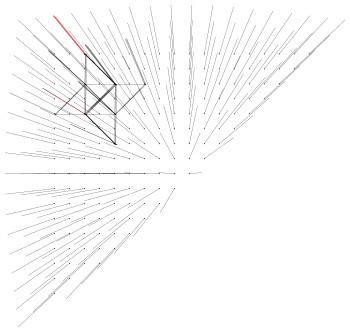

In [17]:
surface_code_circuit.diagram("matchgraph-svg")

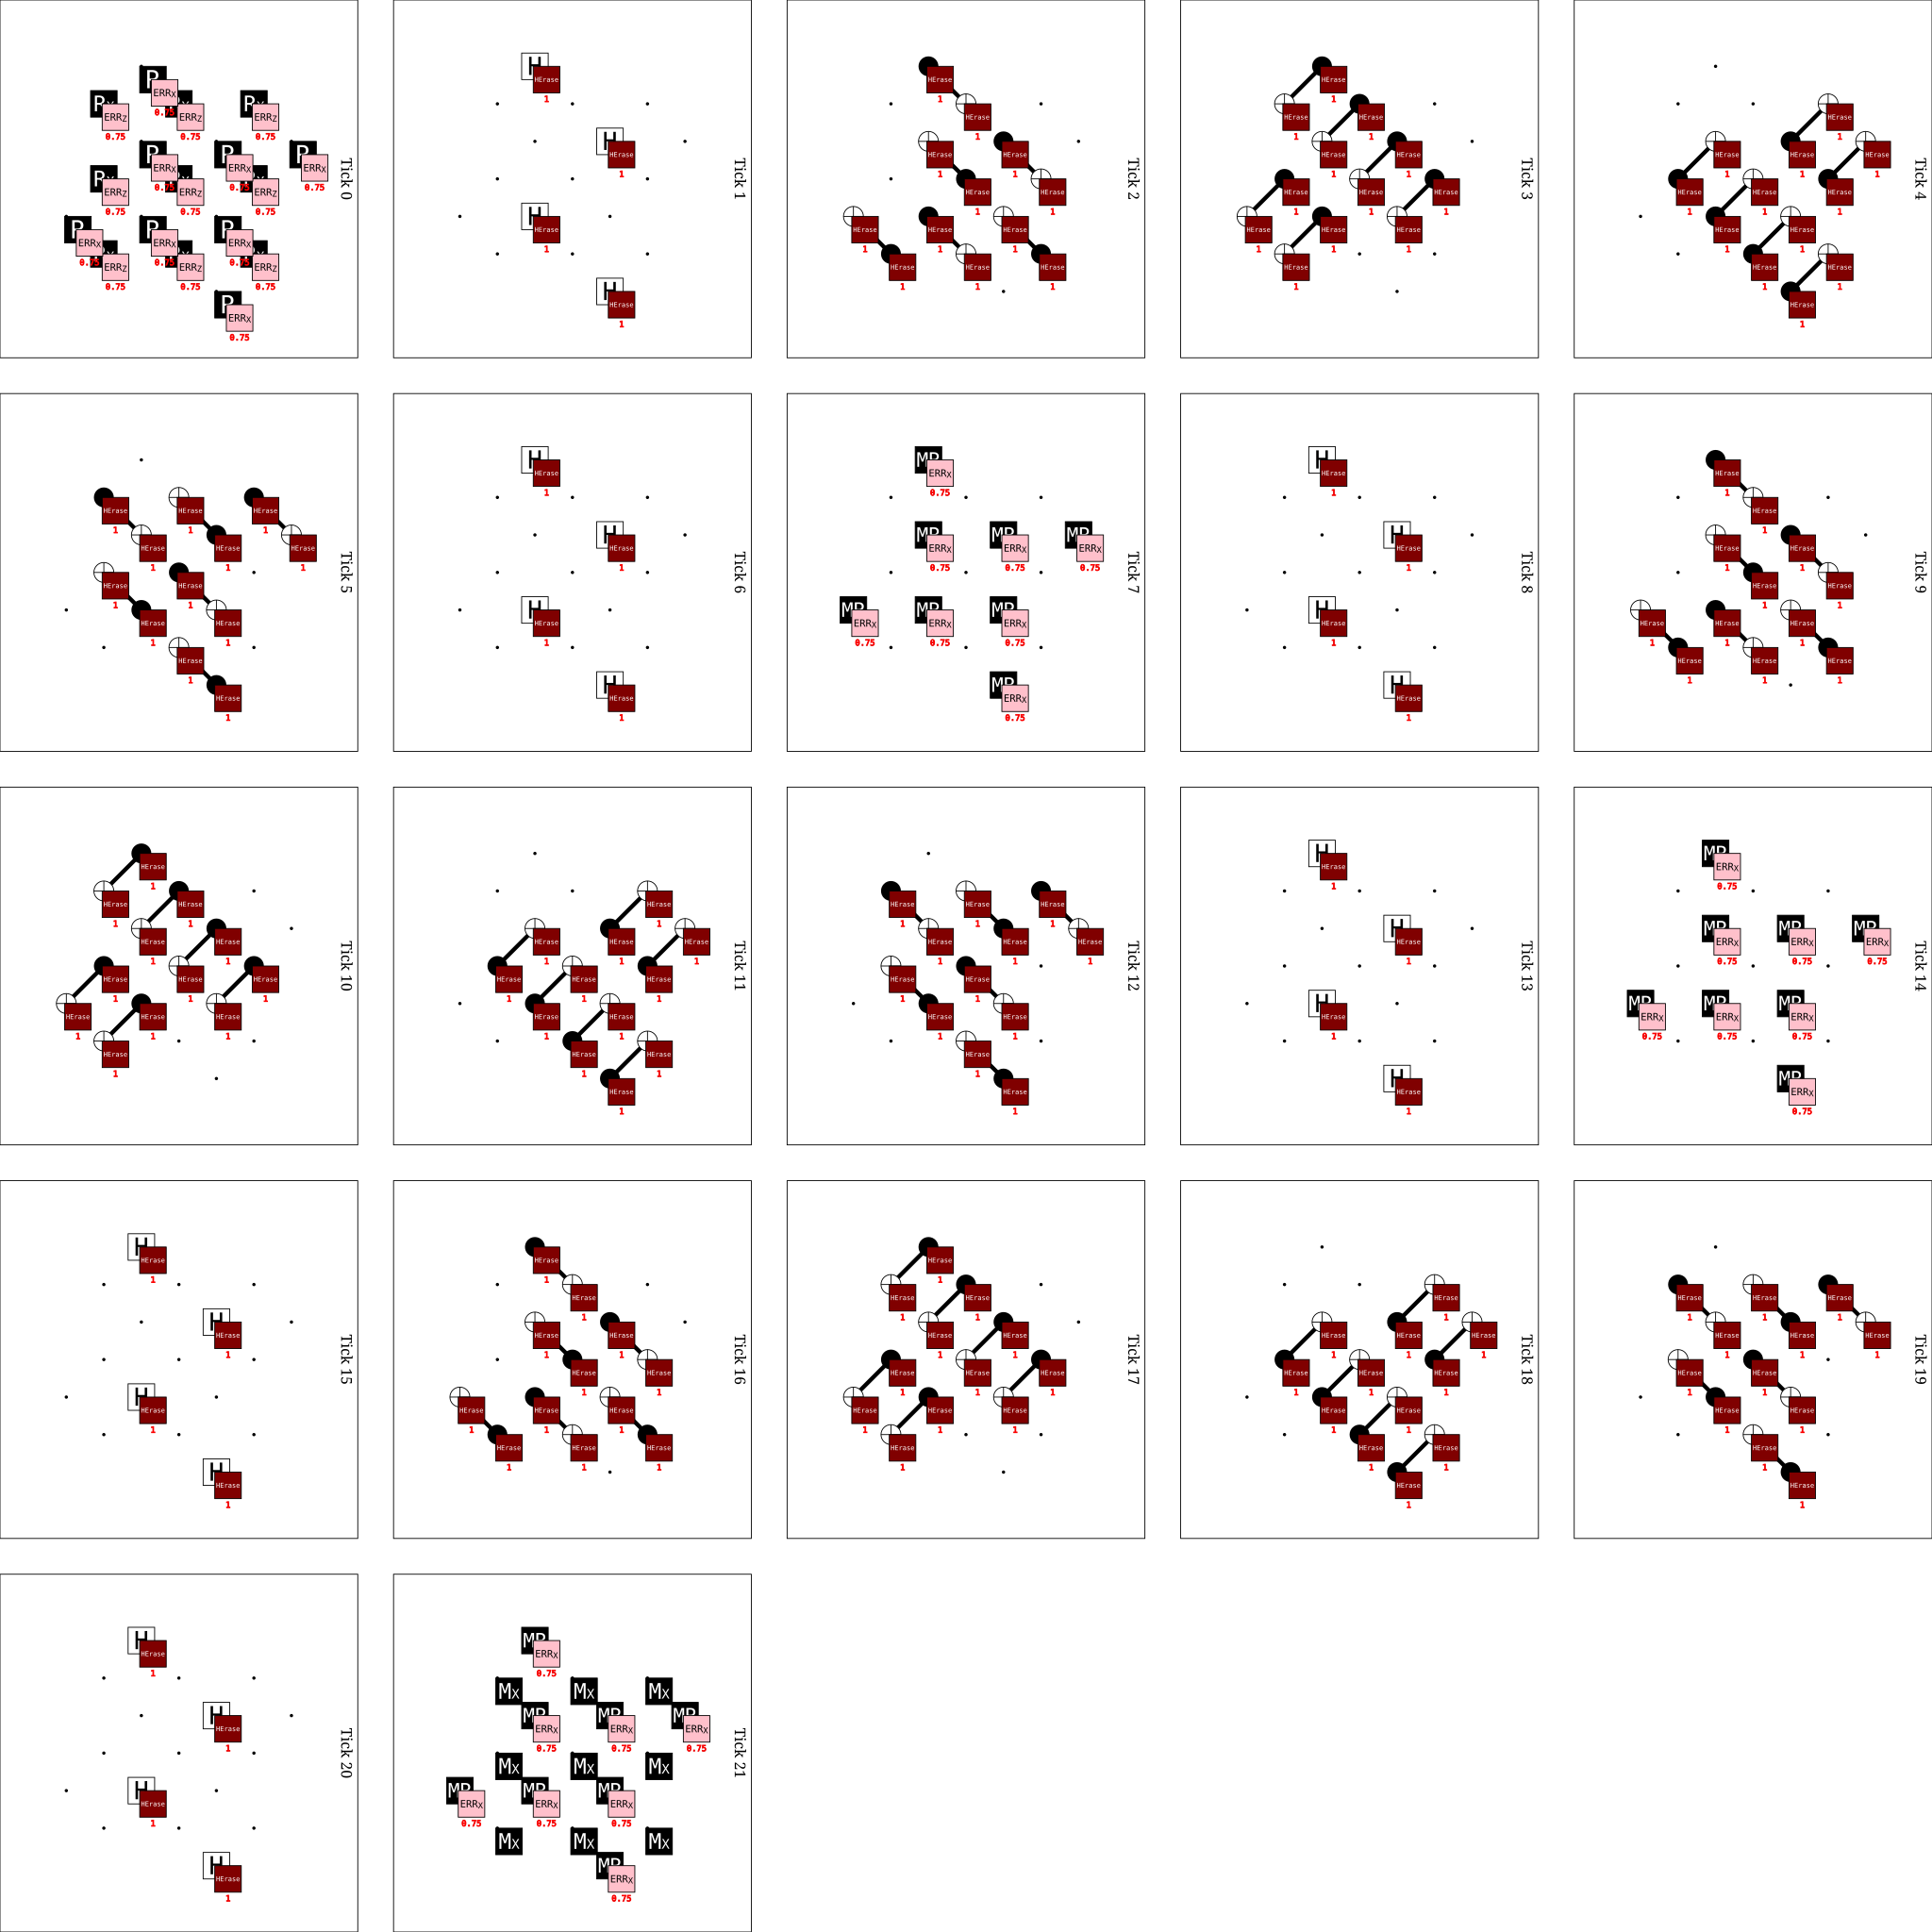

In [18]:
surface_code_circuit.diagram("timeslice-svg")

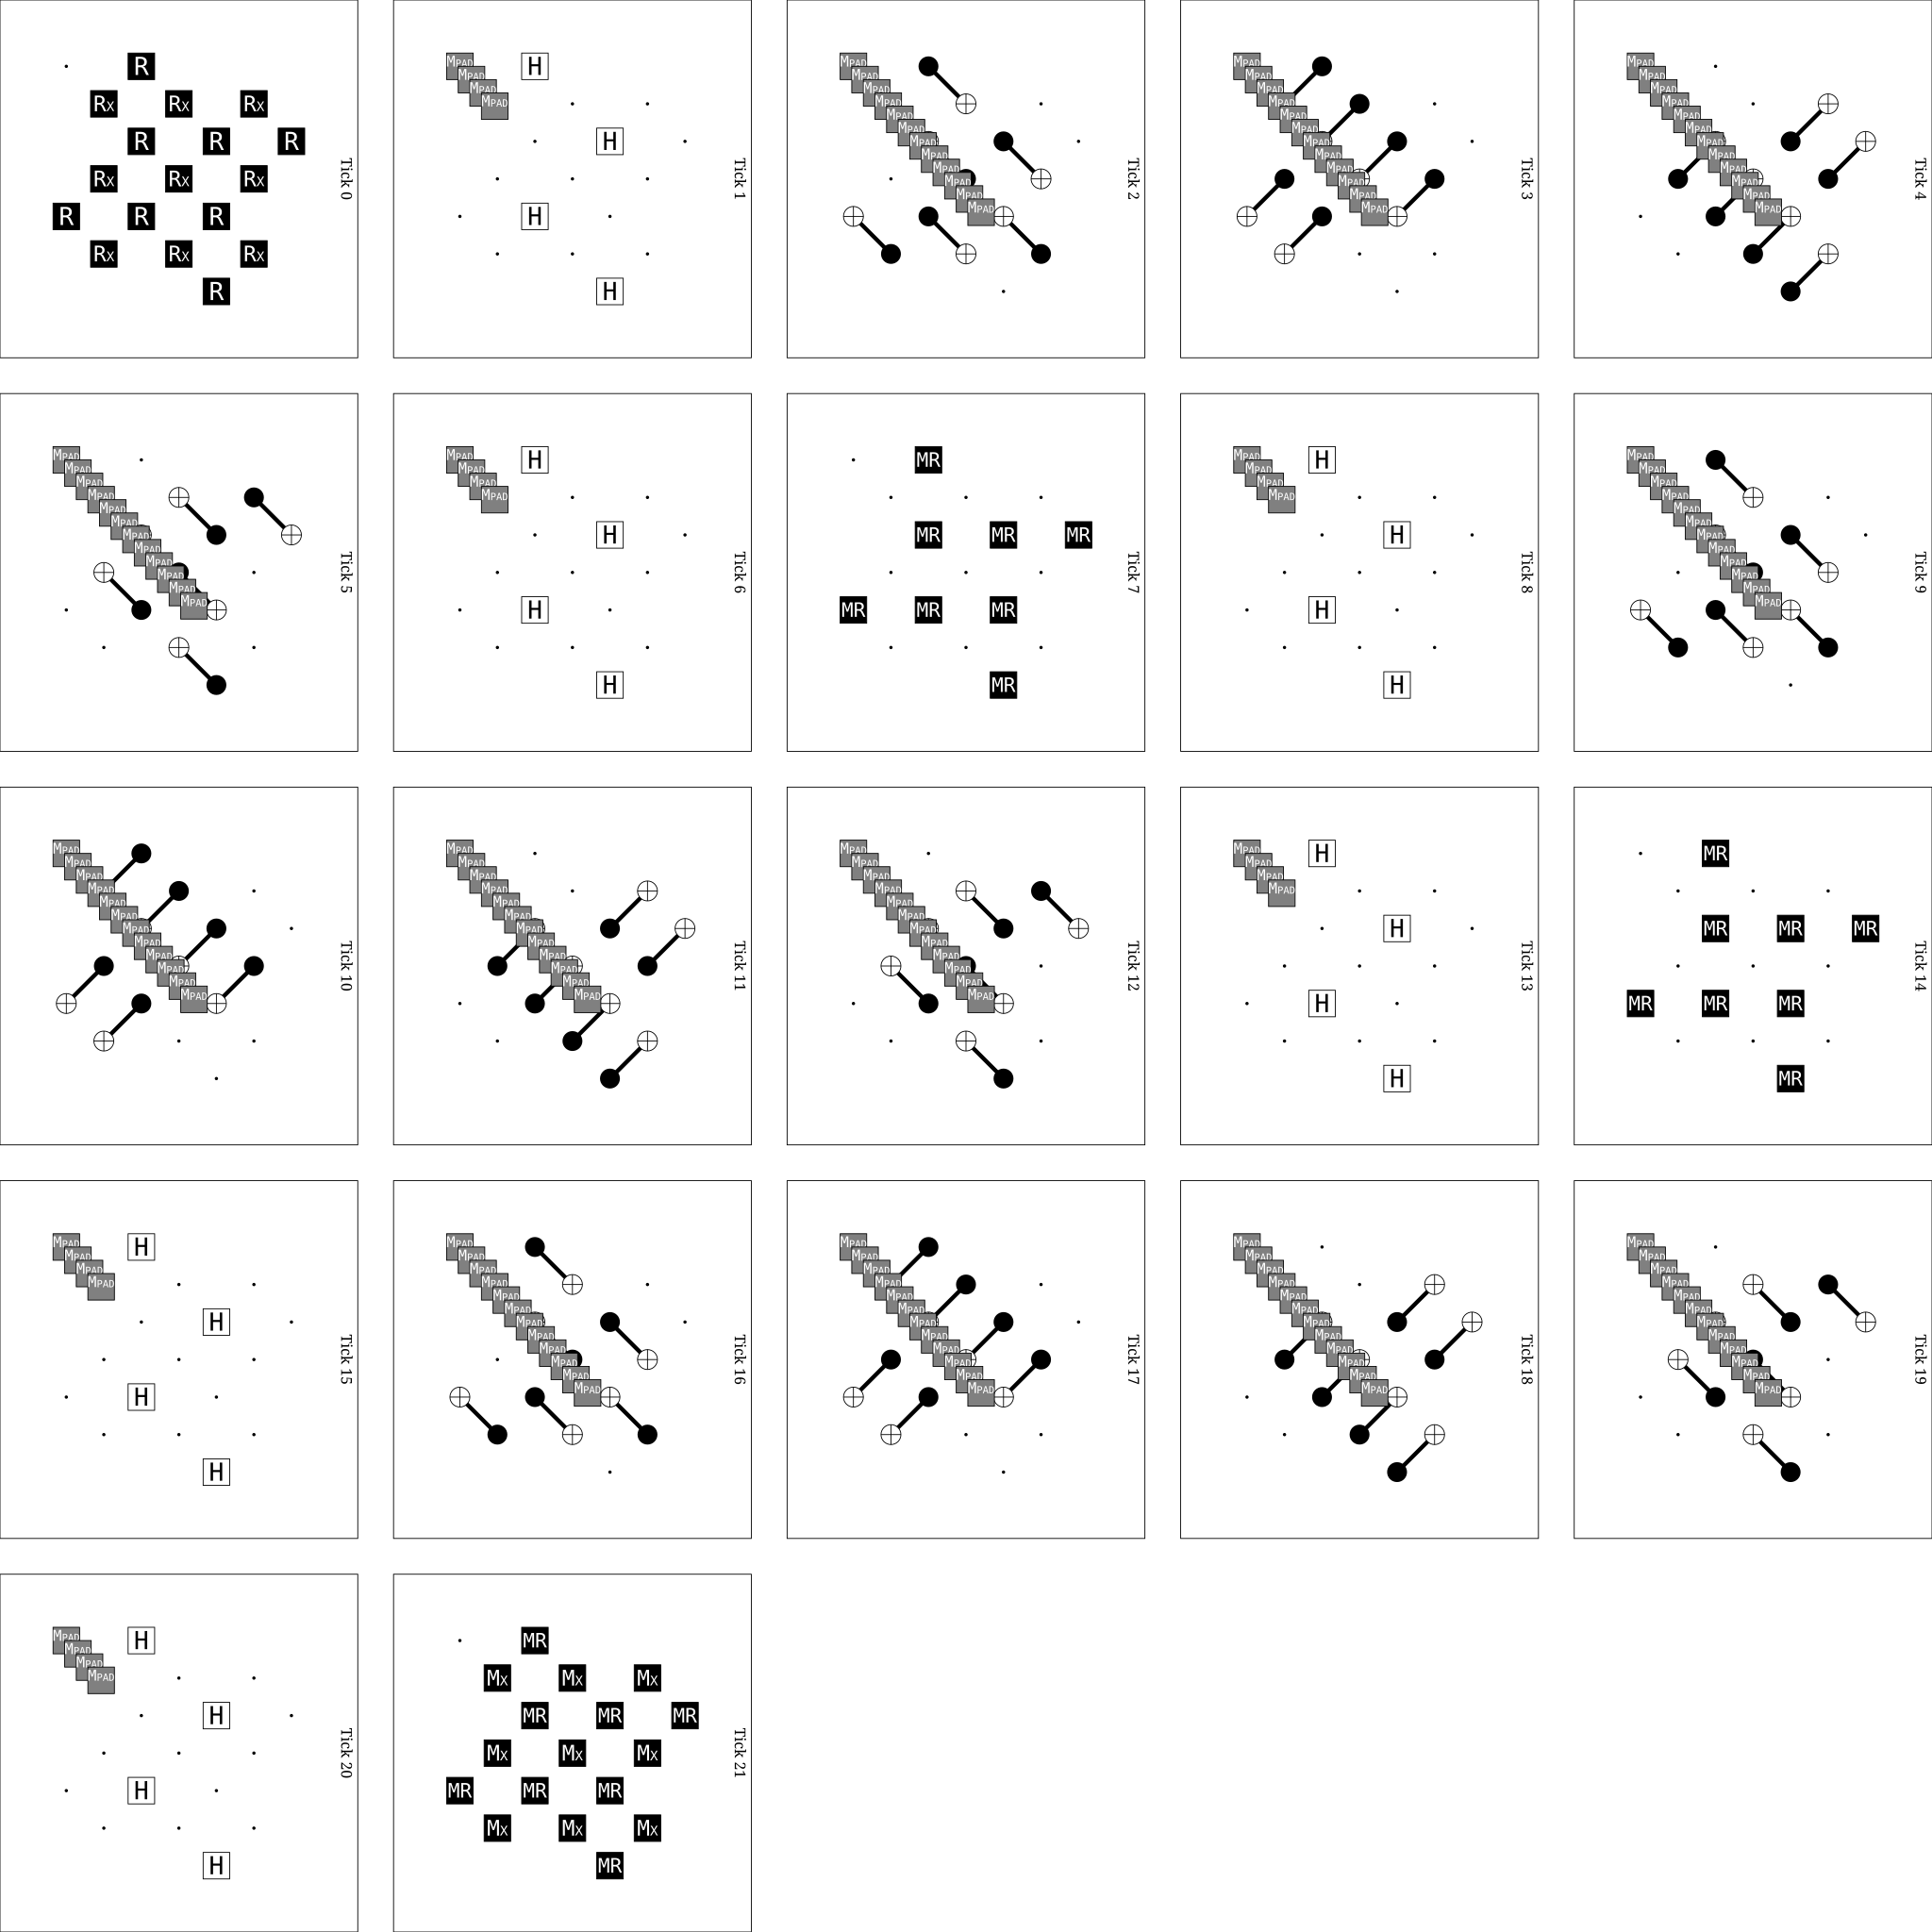

In [19]:
surface_code_circuit.without_noise().diagram("timeslice-svg")